# Gaussian Transformation

Some machine learning models like linear and logistic regression assume that the variables are normally distributed. Often, variables are not normally distributed, but, transforming the variables to map their distribution to a Gaussian distribution may, and often does, boost the performance of the machine learning algorithm.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import scipy.stats as stats
from sklearn.preprocessing import FunctionTransformer, PowerTransformer

In [2]:
data = pd.read_csv('houseprice.csv')

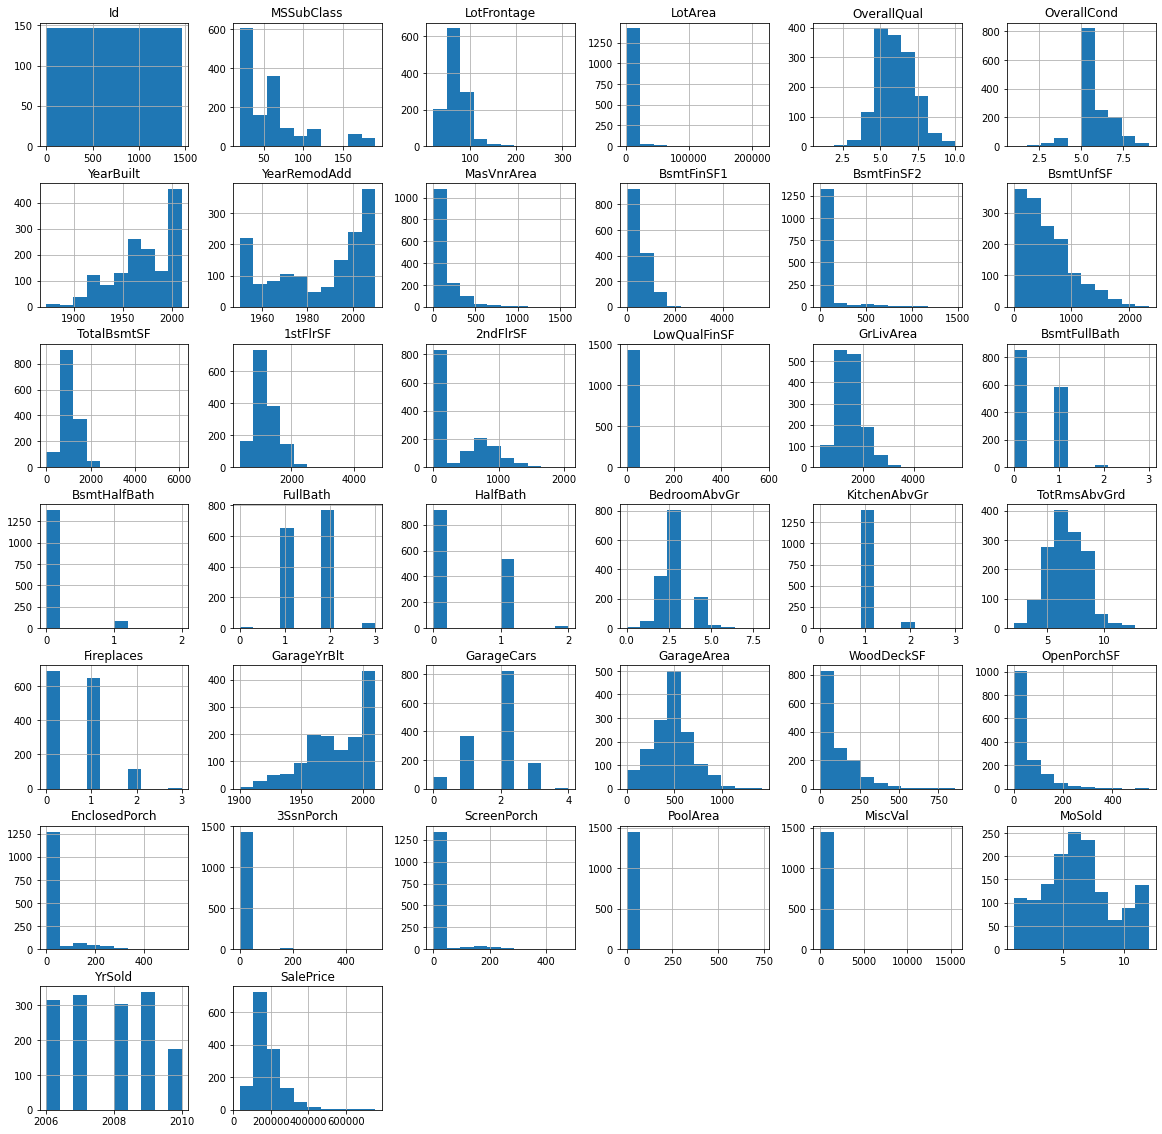

In [3]:
data.hist(figsize=(20,20), bins=10)
plt.show()

### Logarithmic transformation

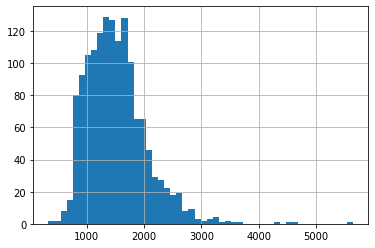

In [ ]:

data['GrLivArea'].hist(bins=50)


In [ ]:
data['GrLivArea_log'] = np.log(data['GrLivArea'])

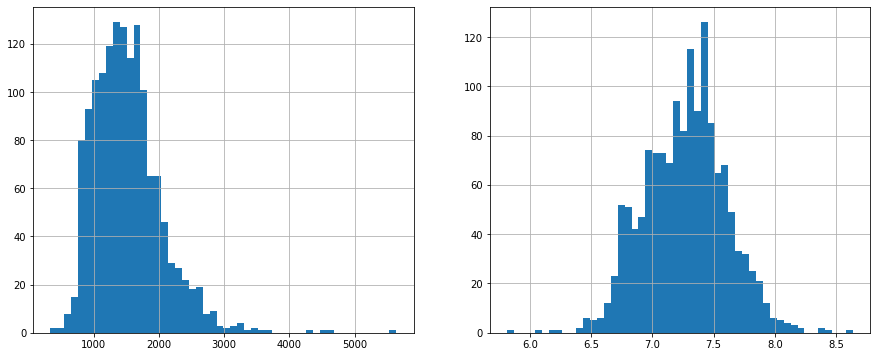

In [ ]:
plt.figure(figsize=(15,6))
plt.subplot(1, 2, 1)
data['GrLivArea'].hist(bins=50)

plt.subplot(1, 2, 2)
data['GrLivArea_log'].hist(bins=50)

#### Sklearn

In [4]:
# create a log transformer
transformer = FunctionTransformer(np.log, validate=True)

In [5]:
from sklearn.compose import ColumnTransformer

In [6]:
preprocessor = ColumnTransformer(transformers=[
    ('transformer', transformer, ["GrLivArea"])], remainder='passthrough')

In [7]:
preprocessor.fit(data)

ColumnTransformer(remainder='passthrough',
                  transformers=[('transformer',
                                 FunctionTransformer(func=<ufunc 'log'>,
                                                     validate=True),
                                 ['GrLivArea'])])

In [8]:
preprocessor.transform(data)

array([[7.444248649496705, 1, 60, ..., 'WD', 'Normal', 208500],
       [7.140453043101158, 2, 20, ..., 'WD', 'Normal', 181500],
       [7.487733761436444, 3, 60, ..., 'WD', 'Normal', 223500],
       ...,
       [7.757906208351747, 1458, 70, ..., 'WD', 'Normal', 266500],
       [6.982862751468942, 1459, 20, ..., 'WD', 'Normal', 142125],
       [7.135687347028144, 1460, 20, ..., 'WD', 'Normal', 147500]],
      dtype=object)

In [9]:
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [10]:
rem = list(data.columns)
rem.remove('GrLivArea')
rem.insert(0,'GrLivArea')

In [ ]:
data_t = pd.DataFrame(preprocessor.transform(data), columns = rem)

In [ ]:
data_t

,GrLivArea,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,...,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,GrLivArea_log
0,7.44425,1,60,RL,65,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,...,Y,SBrkr,856,854,0,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,7.44425
1,7.14045,2,20,RL,80,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,...,Y,SBrkr,1262,0,0,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,7.14045
2,7.48773,3,60,RL,68,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,...,Y,SBrkr,920,866,0,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,7.48773
3,7.44833,4,70,RL,60,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,...,Y,SBrkr,961,756,0,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,7.44833
4,7.6953,5,60,RL,84,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,...,Y,SBrkr,1145,1053,0,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,7.6953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,7.40671,1456,60,RL,62,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,None,0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,...,Y,SBrkr,953,694,0,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000,7.40671
1456,7.63675,1457,20,RL,85,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,...,Y,SBrkr,2073,0,0,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000,7.63675
1457,7.75791,1458,70,RL,66,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,None,0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,...,Y,SBrkr,1188,1152,0,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500,7.75791
1458,6.98286,1459,20,RL,68,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,None,0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,

### Reciprocal transformation

In [11]:
data['GrLivArea_reciprocal'] = 1 / (data['GrLivArea']) 

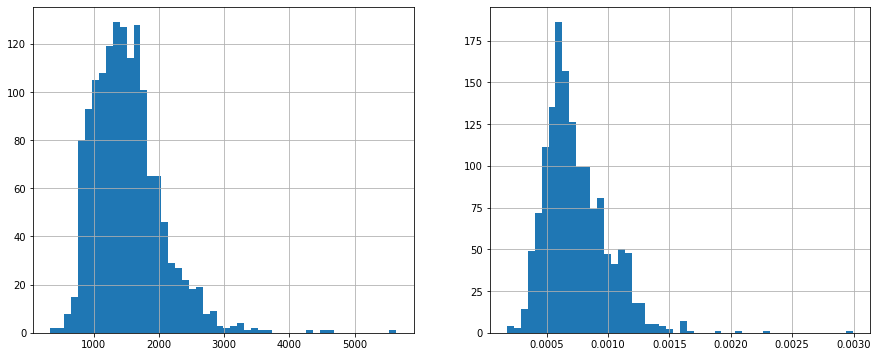

In [12]:
plt.figure(figsize=(15,6))
plt.subplot(1, 2, 1)
data['GrLivArea'].hist(bins=50)

plt.subplot(1, 2, 2)
data['GrLivArea_reciprocal'].hist(bins=50)

#### Sklearn

In [13]:
# create a log transformer
transformer = FunctionTransformer(lambda x : 1 /x, validate=True)

In [14]:
from sklearn.compose import ColumnTransformer

In [15]:
preprocessor = ColumnTransformer(transformers=[
    ('transformer', transformer, ["GrLivArea"])], remainder='passthrough')

In [16]:
preprocessor.fit(data)

ColumnTransformer(remainder='passthrough',
                  transformers=[('transformer',
                                 FunctionTransformer(func=<function <lambda> at 0x7f2a5b12ce60>,
                                                     validate=True),
                                 ['GrLivArea'])])

In [17]:
preprocessor.transform(data)

array([[0.0005847953216374269, 1, 60, ..., 'Normal', 208500,
        0.0005847953216374269],
       [0.000792393026941363, 2, 20, ..., 'Normal', 181500,
        0.000792393026941363],
       [0.0005599104143337066, 3, 60, ..., 'Normal', 223500,
        0.0005599104143337066],
       ...,
       [0.00042735042735042735, 1458, 70, ..., 'Normal', 266500,
        0.00042735042735042735],
       [0.0009276437847866419, 1459, 20, ..., 'Normal', 142125,
        0.0009276437847866419],
       [0.0007961783439490446, 1460, 20, ..., 'Normal', 147500,
        0.0007961783439490446]], dtype=object)

### Square root transformation

In [ ]:
data['GrLivArea_sqr'] = data['GrLivArea']**(1/2) 

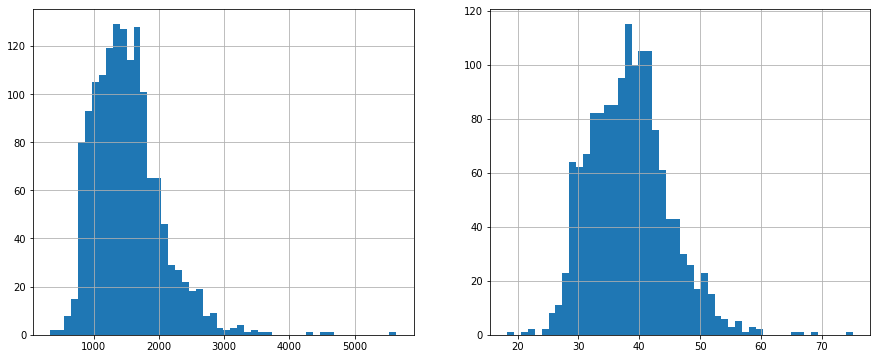

In [ ]:
plt.figure(figsize=(15,6))
plt.subplot(1, 2, 1)
data['GrLivArea'].hist(bins=50)

plt.subplot(1, 2, 2)
data['GrLivArea_sqr'].hist(bins=50)

### Exponential

In [ ]:
data['GrLivArea_exp'] = data['GrLivArea']**(1/1.5) 

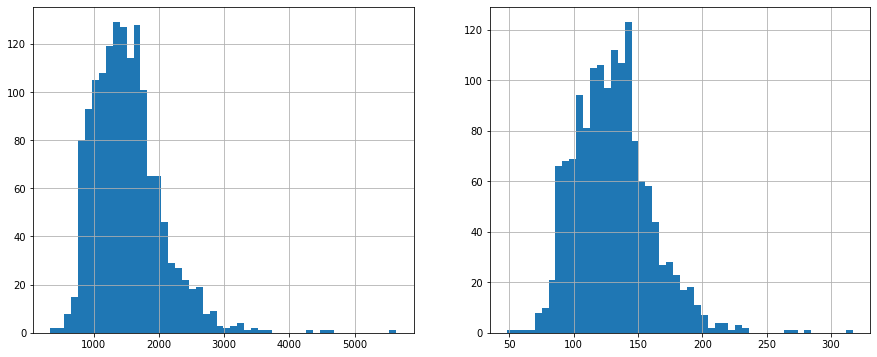

In [ ]:
plt.figure(figsize=(15,6))
plt.subplot(1, 2, 1)
data['GrLivArea'].hist(bins=50)

plt.subplot(1, 2, 2)
data['GrLivArea_exp'].hist(bins=50)

### Box-Cox transformation

The Box-Cox transformation is defined as: 

T(Y)=(Y exp(λ)−1)/λ if λ!=0, or log(Y) otherwise. 

where Y is the response variable and λ is the transformation parameter. λ varies from -5 to 5. In the transformation, all values of λ  are considered and the optimal value for a given variable is selected.




In [ ]:
data['GrLivArea_boxcox'], param = stats.boxcox(data['GrLivArea']) 

print('Optimal λ: ', param)

Optimal λ:  0.006304841218621503


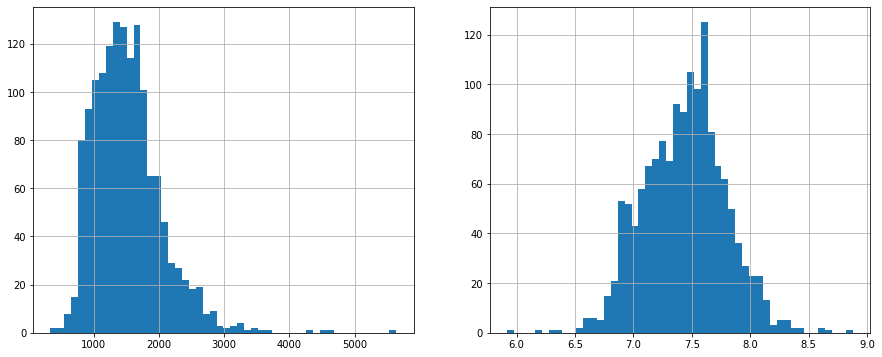

In [ ]:
plt.figure(figsize=(15,6))
plt.subplot(1, 2, 1)
data['GrLivArea'].hist(bins=50)

plt.subplot(1, 2, 2)
data['GrLivArea_boxcox'].hist(bins=50)

### Sklearn

In [ ]:
# create the transformer
transformer = PowerTransformer(method='box-cox', standardize=False)

# find the optimal lambda using the train set
transformer.fit(data[['GrLivArea']])

# transform the data
data_t = transformer.transform(data[['GrLivArea']].fillna(1))


In [ ]:
data_t

array([[7.62171133],
       [7.30362196],
       [7.66729231],
       ...,
       [7.95076655],
       [7.13885679],
       [7.29863688]])

(array([  1.,   0.,   0.,   0.,   1.,   0.,   1.,   1.,   0.,   0.,   2.,
          6.,   6.,   5.,  15.,  21.,  53.,  52.,  43.,  58.,  67.,  70.,
         77.,  69.,  92.,  89., 105.,  98., 125.,  81.,  67.,  62.,  50.,
         36.,  27.,  23.,  23.,  13.,   3.,   5.,   5.,   2.,   2.,   0.,
          0.,   2.,   1.,   0.,   0.,   1.]),
 array([5.91890833, 5.97808097, 6.03725361, 6.09642625, 6.1555989 ,
        6.21477154, 6.27394418, 6.33311682, 6.39228946, 6.4514621 ,
        6.51063475, 6.56980739, 6.62898003, 6.68815267, 6.74732531,
        6.80649795, 6.8656706 , 6.92484324, 6.98401588, 7.04318852,
        7.10236116, 7.16153381, 7.22070645, 7.27987909, 7.33905173,
        7.39822437, 7.45739701, 7.51656966, 7.5757423 , 7.63491494,
        7.69408758, 7.75326022, 7.81243286, 7.87160551, 7.93077815,
        7.98995079, 8.04912343, 8.10829607, 8.16746871, 8.22664136,
        8.285814  , 8.34498664, 8.40415928, 8.46333192, 8.52250457,
        8.58167721, 8.64084985, 8.70002249, 8.

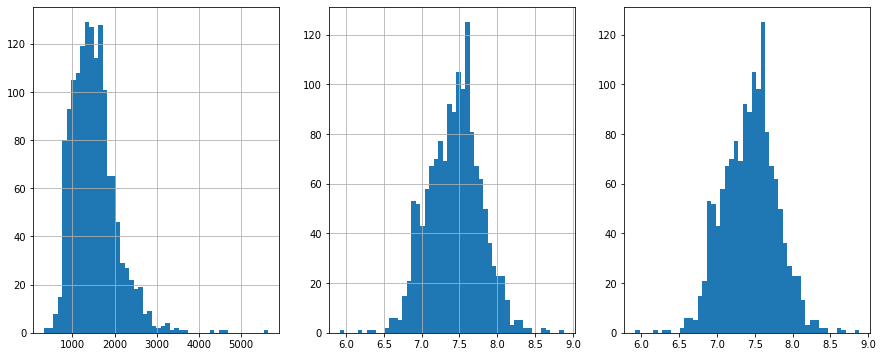

In [ ]:
plt.figure(figsize=(15,6))
plt.subplot(1, 3, 1)
data['GrLivArea'].hist(bins=50)

plt.subplot(1, 3, 2)
data['GrLivArea_boxcox'].hist(bins=50)

plt.subplot(1, 3, 3)
plt.hist(data_t, bins=50)

#Feature Scaling

## Standardisation


Standardisation involves centering the variable at zero, and standardising the variance to 1. The procedure involves subtracting the mean of each observation and then dividing by the standard deviation:

**z = (x - x_mean) /  std**

The result of the above transformation is **z**, which is called the z-score, and represents how many standard deviations a given observation deviates from the mean.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



# the scaler - for standardisation
from sklearn.preprocessing import StandardScaler

In [ ]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,GrLivArea_log,GrLivArea_reciprocal,GrLivArea_sqr,GrLivArea_exp,GrLivArea_boxcox
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890,7.267774,0.000738,38.389673,130.308718,7.437227
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883,0.333550,0.000256,6.459510,29.452518,0.349189
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000,5.811141,0.000177,18.275667,48.139064,5.918908
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000,7.029530,0.000563,33.608032,108.456969,7.187632
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000,7.288928,0.000683,38.262253,128.931999,7.459006
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000,7.482541,0.000885,42.151510,146.695747,7.661848
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.0

In [ ]:
data[['LotArea',	'OverallQual',	'OverallCond']].describe()

,LotArea,OverallQual,OverallCond
count,1460.000000,1460.000000,1460.000000
mean,10516.828082,6.099315,5.575342
std,9981.264932,1.382997,1.112799
min,1300.000000,1.000000,1.000000
25%,7553.500000,5.000000,5.000000
50%,9478.500000,6.000000,5.000000
75%,11601.500000,7.000000,6.000000
max,215245.000000,10.000000,9.000000


In [ ]:
scaler = StandardScaler()

In [ ]:
scaler.fit(data[['LotArea',	'OverallQual',	'OverallCond']])

StandardScaler(copy=True, with_mean=True, with_std=True)

In [ ]:
scaler.mean_

array([1.05168281e+04, 6.09931507e+00, 5.57534247e+00])

In [ ]:
scaled = pd.DataFrame(scaler.transform(data[['LotArea',	'OverallQual',	'OverallCond']]), columns=['LotArea',	'OverallQual',	'OverallCond'])

In [ ]:
scaled.describe()

,LotArea,OverallQual,OverallCond
count,1.460000e+03,1.460000e+03,1.460000e+03
mean,-4.202783e-17,-7.680310e-17,3.692632e-16
std,1.000343e+00,1.000343e+00,1.000343e+00
min,-9.237292e-01,-3.688413e+00,-4.112970e+00
25%,-2.969908e-01,-7.951515e-01,-5.171998e-01
50%,-1.040633e-01,-7.183611e-02,-5.171998e-01
75%,1.087080e-01,6.514792e-01,3.817427e-01
max,2.051827e+01,2.821425e+00,3.078570e+00


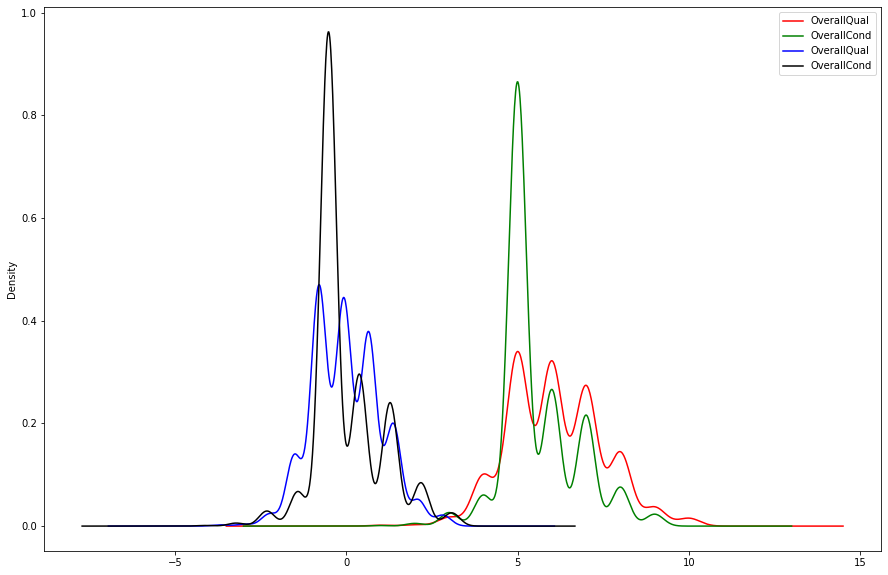

In [ ]:
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(111)

#data["LotArea"].plot(kind='kde', ax=ax)
data["OverallQual"].plot(kind='kde', ax=ax, color='red')
data["OverallCond"].plot(kind='kde', ax=ax, color='green')
scaled["OverallQual"].plot(kind='kde', ax=ax, color='blue')
scaled["OverallCond"].plot(kind='kde', ax=ax, color='black')

ax.legend(loc='best')

## Mean Normalisation


**x_scaled = (x - x_mean) / ( x_max - x_min)**


The result of the above transformation is a distribution that is centered at 0, and its minimum and maximum values are within the range of -1 to 1. The shape of a mean normalised distribution will be very similar to the original distribution of the variable, but the variance may change, so not identical.

In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler

In [ ]:
# set up the StandardScaler so that it removes the mean
# but does not divide by the standard deviation
scaler_mean = StandardScaler(with_mean=True, with_std=False)

# set up the robustscaler so that it does NOT remove the median
# but normalises by max()-min(), important for this to set up the
# quantile range to 0 and 100, which represent the min and max values
scaler_minmax = RobustScaler(with_centering=False,
                             with_scaling=True,
                             quantile_range=(0, 100))

In [ ]:
scaler_mean.fit(data[['LotArea',	'OverallQual',	'OverallCond']])
scaler_minmax.fit(data[['LotArea',	'OverallQual',	'OverallCond']])

RobustScaler(copy=True, quantile_range=(0, 100), with_centering=False,
             with_scaling=True)

In [ ]:
mean_scaled = scaler_minmax.transform(scaler_mean.transform(data[['LotArea',	'OverallQual',	'OverallCond']]))

In [ ]:
df_mean_scaled=pd.DataFrame(mean_scaled, columns=['LotArea',	'OverallQual',	'OverallCond'])

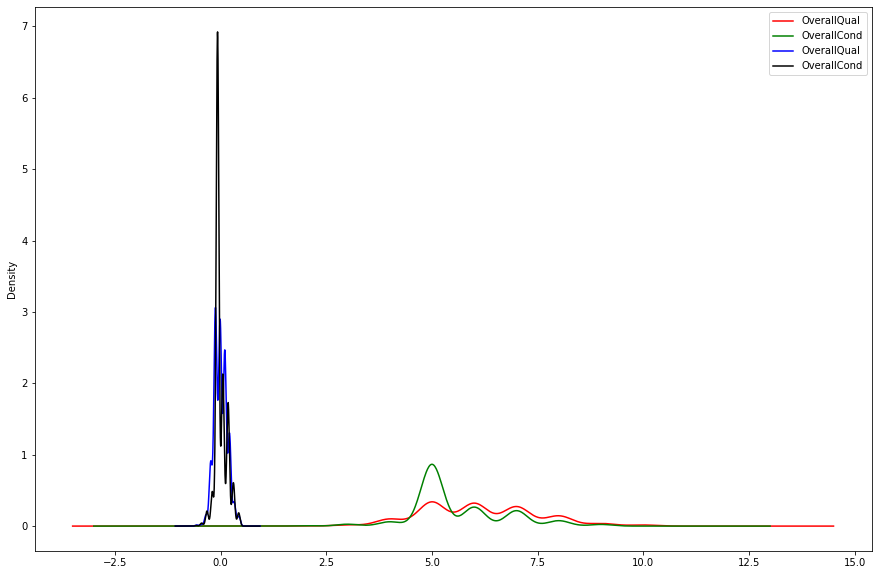

In [ ]:
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(111)

#data["LotArea"].plot(kind='kde', ax=ax)
data["OverallQual"].plot(kind='kde', ax=ax, color='red')
data["OverallCond"].plot(kind='kde', ax=ax, color='green')
df_mean_scaled["OverallQual"].plot(kind='kde', ax=ax, color='blue')
df_mean_scaled["OverallCond"].plot(kind='kde', ax=ax, color='black')

ax.legend(loc='best')

## Scaling to Minimum and Maximum values - MinMaxScaling

Minimum and maximum scaling squeezes the values between 0 and 1. It subtracts the minimum value from all the observations, and then divides it by the value range:

X_scaled = (X - X.min / (X.max - X.min)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler_minmax = MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler_minmax.fit(data[['LotArea',	'OverallQual',	'OverallCond']])

MinMaxScaler(copy=True, feature_range=(0, 1))

In [ ]:
minmax_scaled = pd.DataFrame(scaler_minmax.transform(data[['LotArea',	'OverallQual',	'OverallCond']]), columns=['LotArea',	'OverallQual',	'OverallCond'])

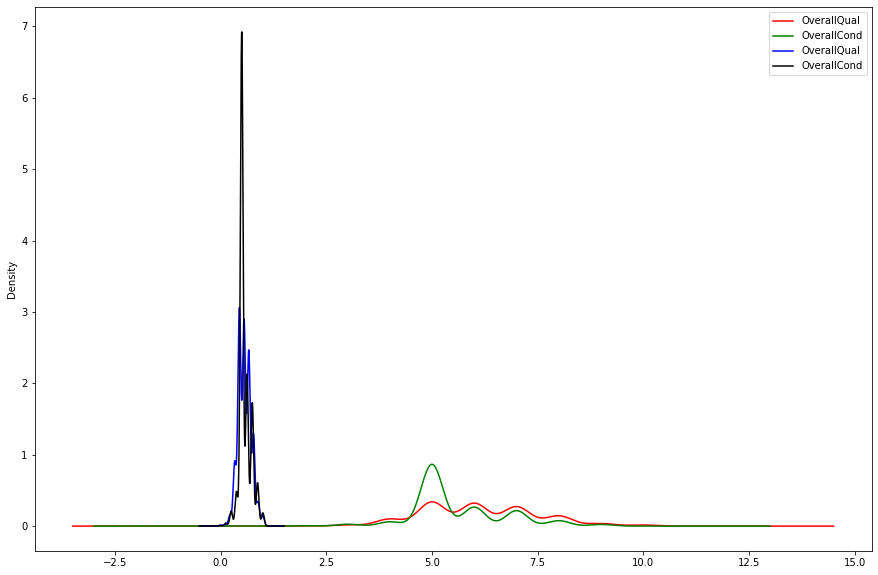

In [ ]:
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(111)

#data["LotArea"].plot(kind='kde', ax=ax)
data["OverallQual"].plot(kind='kde', ax=ax, color='red')
data["OverallCond"].plot(kind='kde', ax=ax, color='green')
minmax_scaled["OverallQual"].plot(kind='kde', ax=ax, color='blue')
minmax_scaled["OverallCond"].plot(kind='kde', ax=ax, color='black')

ax.legend(loc='best')

## Scaling to maximum value - MaxAbsScaling

Maximum absolute scaling scales the data to its absolute maximum value:

X_scaled = X / abs(X.max)

The result of the above transformation is a distribution which values vary within the range of -1 to 1. But the mean is not centered at zero and the standard deviation varies across variables.

Scikit-learn suggests that this transformer is meant for data that is centered at zero, and for sparse data.

In [ ]:
from sklearn.preprocessing import MaxAbsScaler, StandardScaler

In [ ]:
scaler_maxabs = MaxAbsScaler()

# fit the scaler to the train set, it will learn the parameters
scaler_maxabs.fit(data[['LotArea',	'OverallQual',	'OverallCond']])

MaxAbsScaler(copy=True)

In [ ]:
scaled_maxabs = pd.DataFrame(scaler_maxabs.transform(data[['LotArea',	'OverallQual',	'OverallCond']]), columns=['LotArea',	'OverallQual',	'OverallCond'])

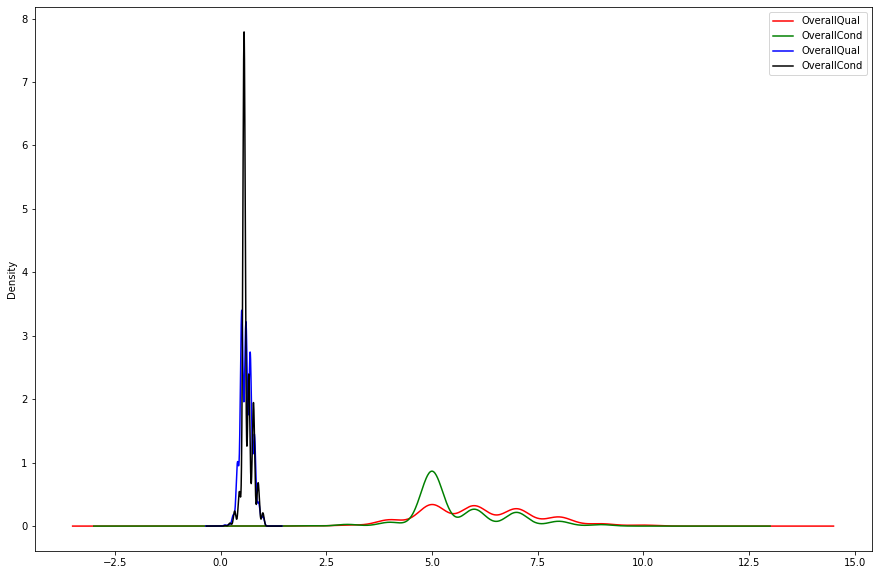

In [ ]:
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(111)

#data["LotArea"].plot(kind='kde', ax=ax)
data["OverallQual"].plot(kind='kde', ax=ax, color='red')
data["OverallCond"].plot(kind='kde', ax=ax, color='green')
scaled_maxabs["OverallQual"].plot(kind='kde', ax=ax, color='blue')
scaled_maxabs["OverallCond"].plot(kind='kde', ax=ax, color='black')

ax.legend(loc='best')


## Scaling to quantiles and median - RobustScaling

In this procedure the median is removed from the observations and then they are scaled to the inter-quantile range (IQR). The IQR is the range between the 1st quartile (25th quantile) and the 3rd quartile (75th quantile).

X_scaled = X - X_median / ( X.quantile(0.75) - X.quantile(0.25) )

In [ ]:
from sklearn.preprocessing import RobustScaler

In [ ]:
scaler_robust= RobustScaler()

# fit the scaler to the train set, it will learn the parameters
scaler_robust.fit(data[['LotArea',	'OverallQual',	'OverallCond']])

RobustScaler(copy=True, quantile_range=(25.0, 75.0), with_centering=True,
             with_scaling=True)

In [ ]:
scaled_robust = pd.DataFrame(scaler_robust.transform(data[['LotArea',	'OverallQual',	'OverallCond']]), columns=['LotArea',	'OverallQual',	'OverallCond'])

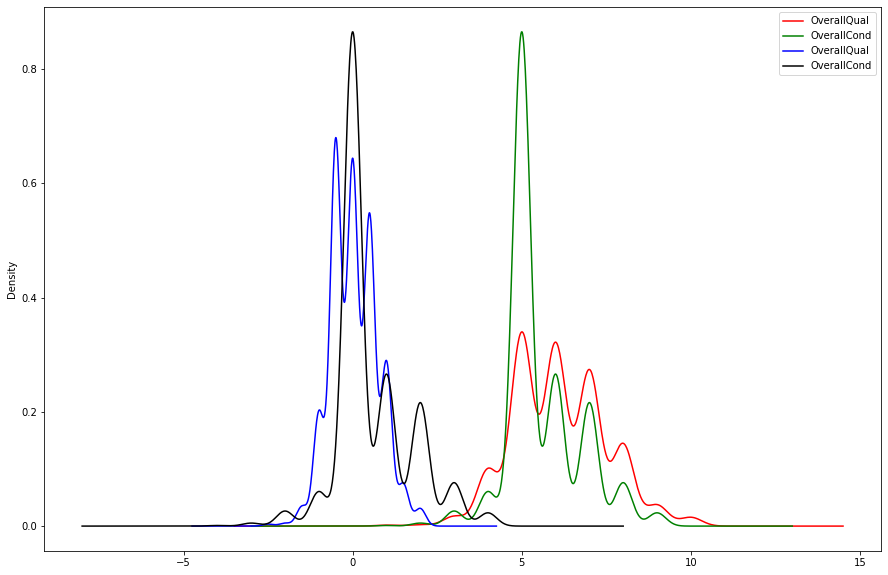

In [ ]:
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(111)

#data["LotArea"].plot(kind='kde', ax=ax)
data["OverallQual"].plot(kind='kde', ax=ax, color='red')
data["OverallCond"].plot(kind='kde', ax=ax, color='green')
scaled_robust["OverallQual"].plot(kind='kde', ax=ax, color='blue')
scaled_robust["OverallCond"].plot(kind='kde', ax=ax, color='black')

ax.legend(loc='best')

The median of the distributions are centered at zero, but every other parameter may vary in the different variables

## Scaling to vector unit  length / unit norm

In this procedure we scale the components of a feature vector such that the complete vector has a length of 1 or, in other words a norm of 1.

In [ ]:
from sklearn.preprocessing import Normalizer

In [ ]:
normalizer= Normalizer()

# fit the scaler to the train set, it will learn the parameters
normalizer.fit(data[['LotArea',	'OverallQual',	'OverallCond']])

Normalizer(copy=True, norm='l2')

In [ ]:
scaled_normalizer = pd.DataFrame(normalizer.transform(data[['LotArea',	'OverallQual',	'OverallCond']]), columns=['LotArea',	'OverallQual',	'OverallCond'])

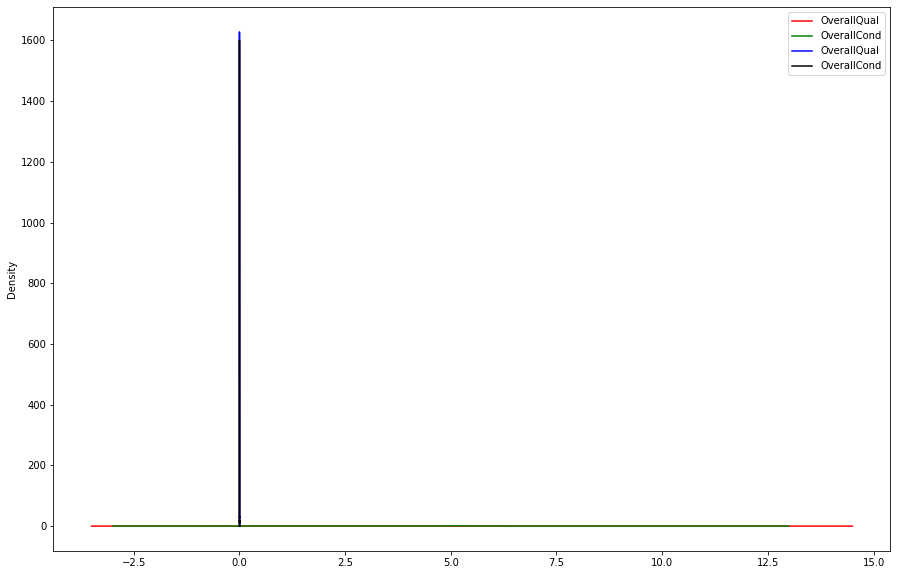

In [ ]:
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(111)

#data["LotArea"].plot(kind='kde', ax=ax)
data["OverallQual"].plot(kind='kde', ax=ax, color='red')
data["OverallCond"].plot(kind='kde', ax=ax, color='green')
scaled_normalizer["OverallQual"].plot(kind='kde', ax=ax, color='blue')
scaled_normalizer["OverallCond"].plot(kind='kde', ax=ax, color='black')

ax.legend(loc='best')

# Discretisation

Discretisation is the process of transforming continuous variables into discrete variables by creating a set of contiguous intervals that span the range of the variable's values. Discretisation is also called **binning**, where bin is an alternative name for interval.

## Equal width discretisation

Equal width discretisation divides the scope of possible values into N bins of the same width.The width is determined by the range of values in the variable and the number of bins we wish to use to divide the variable:

width = (max value - min value) / N

where N is the number of bins or intervals.

In [ ]:
from sklearn.preprocessing import KBinsDiscretizer

In [ ]:
data["LotArea"].describe()

count      1460.000000
mean      10516.828082
std        9981.264932
min        1300.000000
25%        7553.500000
50%        9478.500000
75%       11601.500000
max      215245.000000
Name: LotArea, dtype: float64

In [ ]:
pd.cut(data["LotArea"],bins=10)

0       (1086.054, 22694.5]
1       (1086.054, 22694.5]
2       (1086.054, 22694.5]
3       (1086.054, 22694.5]
4       (1086.054, 22694.5]
               ...         
1455    (1086.054, 22694.5]
1456    (1086.054, 22694.5]
1457    (1086.054, 22694.5]
1458    (1086.054, 22694.5]
1459    (1086.054, 22694.5]
Name: LotArea, Length: 1460, dtype: category
Categories (10, interval[float64]): [(1086.054, 22694.5] < (22694.5, 44089.0] < (44089.0, 65483.5] <
                                     (65483.5, 86878.0] ... (129667.0, 151061.5] <
                                     (151061.5, 172456.0] < (172456.0, 193850.5] < (193850.5, 215245.0]]

In [ ]:
out,bins= pd.cut(data["LotArea"],bins=10, retbins = True)

In [ ]:
out

0       (1086.055, 22694.5]
1       (1086.055, 22694.5]
2       (1086.055, 22694.5]
3       (1086.055, 22694.5]
4       (1086.055, 22694.5]
               ...         
1455    (1086.055, 22694.5]
1456    (1086.055, 22694.5]
1457    (1086.055, 22694.5]
1458    (1086.055, 22694.5]
1459    (1086.055, 22694.5]
Name: LotArea, Length: 1460, dtype: category
Categories (10, interval[float64]): [(1086.055, 22694.5] < (22694.5, 44089.0] < (44089.0, 65483.5] <
                                     (65483.5, 86878.0] ... (129667.0, 151061.5] <
                                     (151061.5, 172456.0] < (172456.0, 193850.5] < (193850.5, 215245.0]]

In [ ]:
bins

array([  1086.055,  22694.5  ,  44089.   ,  65483.5  ,  86878.   ,
       108272.5  , 129667.   , 151061.5  , 172456.   , 193850.5  ,
       215245.   ])

In [ ]:
out.unique()

[(1086.055, 22694.5], (44089.0, 65483.5], (22694.5, 44089.0], (151061.5, 172456.0], (193850.5, 215245.0], (65483.5, 86878.0], (108272.5, 129667.0]]
Categories (7, interval[float64]): [(1086.055, 22694.5] < (22694.5, 44089.0] < (44089.0, 65483.5] <
                                    (65483.5, 86878.0] < (108272.5, 129667.0] < (151061.5, 172456.0] <
                                    (193850.5, 215245.0]]

In [ ]:
data['LotArea_bin10'] =  pd.cut(data["LotArea"],bins=10, labels=False)


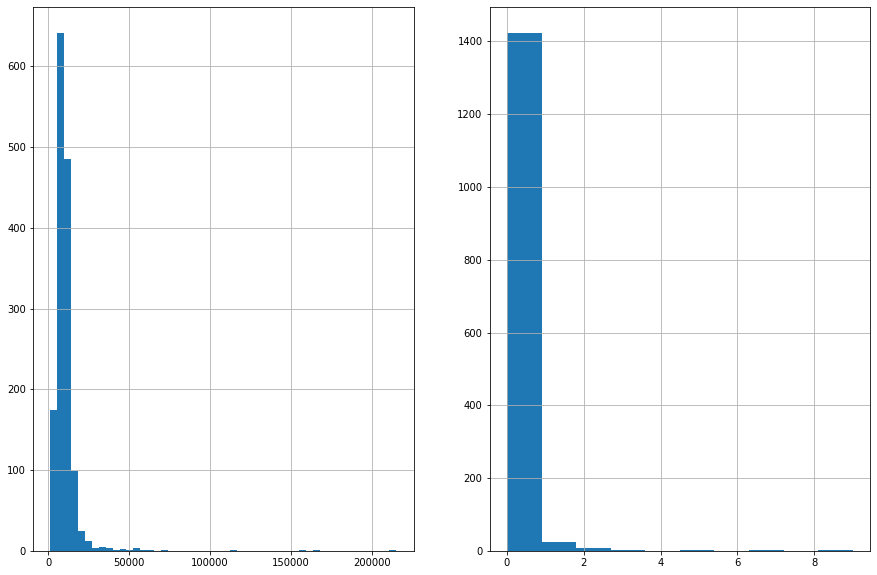

In [ ]:
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(121)

data["LotArea"].hist(bins=50)
ax = fig.add_subplot(122)
data["LotArea_bin10"].hist(bins=10)


### Sklearn

In [ ]:
discr= KBinsDiscretizer(encode='ordinal', n_bins=10, strategy='uniform')

In [ ]:
discr.fit(data[["LotArea"]])

KBinsDiscretizer(encode='ordinal', n_bins=10, strategy='uniform')

In [ ]:
data['LotArea_bin10_sk']= discr.transform(data[["LotArea"]])

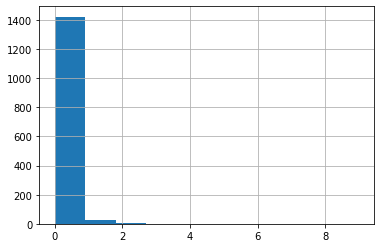

In [ ]:
data['LotArea_bin10_sk'].hist()

In [ ]:
data['LotArea_bin10_sk'].sample(10)

497     0.0
773     0.0
291     0.0
1021    0.0
808     0.0
645     0.0
23      0.0
547     0.0
4       0.0
1356    0.0
Name: LotArea_bin10_sk, dtype: float64

## Equal frequency discretisation

Equal frequency discretisation divides the scope of possible values of the variable into N bins, where each bin carries the same amount of observations. This is particularly useful for skewed variables as it spreads the observations over the different bins equally. We find the interval boundaries by determining the quantiles.

In [ ]:
from sklearn.preprocessing import KBinsDiscretizer

In [ ]:
data["LotArea"].describe()

count      1460.000000
mean      10516.828082
std        9981.264932
min        1300.000000
25%        7553.500000
50%        9478.500000
75%       11601.500000
max      215245.000000
Name: LotArea, dtype: float64

In [ ]:
pd.qcut(data["LotArea"],10)

0         (8063.7, 8793.4]
1        (9478.5, 10198.2]
2       (11066.5, 12205.8]
3        (9478.5, 10198.2]
4       (12205.8, 14381.7]
               ...        
1455      (7078.4, 8063.7]
1456    (12205.8, 14381.7]
1457      (8793.4, 9478.5]
1458     (9478.5, 10198.2]
1459     (9478.5, 10198.2]
Name: LotArea, Length: 1460, dtype: category
Categories (10, interval[float64]): [(1299.999, 5000.0] < (5000.0, 7078.4] < (7078.4, 8063.7] <
                                     (8063.7, 8793.4] ... (10198.2, 11066.5] < (11066.5, 12205.8] <
                                     (12205.8, 14381.7] < (14381.7, 215245.0]]

In [ ]:
data['LotArea_eb']=pd.qcut(data["LotArea"],10)

In [ ]:
data[['LotArea_eb']].value_counts()

LotArea_eb         
(1299.999, 5000.0]     147
(14381.7, 215245.0]    146
(12205.8, 14381.7]     146
(11066.5, 12205.8]     146
(10198.2, 11066.5]     146
(9478.5, 10198.2]      146
(8793.4, 9478.5]       146
(8063.7, 8793.4]       146
(7078.4, 8063.7]       146
(5000.0, 7078.4]       145
dtype: int64

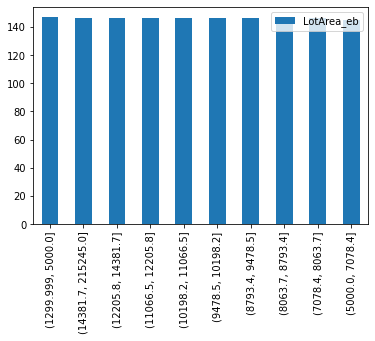

In [ ]:
data[['LotArea_eb']].apply(pd.value_counts).plot(kind='bar')

### Sklearn

In [ ]:
discr= KBinsDiscretizer(encode='ordinal', n_bins=10, strategy='quantile')

In [ ]:
discr.fit(data[["LotArea"]])

KBinsDiscretizer(encode='ordinal', n_bins=10, strategy='quantile')

In [ ]:
data['LotArea_bin10q_sk']= discr.transform(data[["LotArea"]])

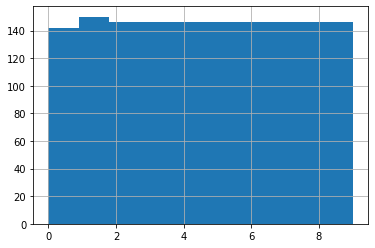

In [ ]:
data['LotArea_bin10q_sk'].hist()

## Discretisation with k-means clustering (Sklearn)

This discretisation method consists in applying k-means clustering to the continuous variable.

In [ ]:
discr = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='kmeans')

discr.fit(data[["LotArea"]])

KBinsDiscretizer(encode='ordinal', n_bins=10, strategy='kmeans')

In [ ]:
data['LotArea_bin10km_sk']= discr.transform(data[["LotArea"]])

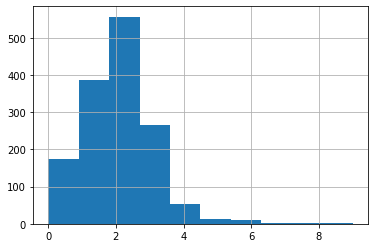

In [ ]:
data['LotArea_bin10km_sk'].hist()

In [ ]:
data['LotArea_bin10km_sk'].value_counts()

2.0    557
1.0    386
3.0    265
0.0    173
4.0     54
5.0     12
6.0      9
8.0      2
7.0      1
9.0      1
Name: LotArea_bin10km_sk, dtype: int64

# Managing Outliers


## Trimming or truncation

Trimming, also known as truncation, involves removing the outliers from the dataset. 


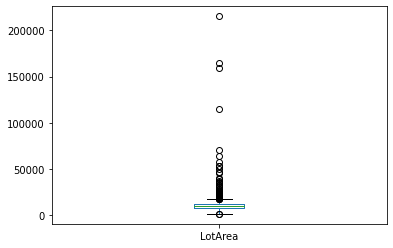

In [ ]:
data[["LotArea"]].plot(kind='box')

In [ ]:
# if gaussian data["LotArea"].mean()+3*data["LotArea"].std()
IQR= data["LotArea"].quantile(0.75)-data["LotArea"].quantile(0.25)

In [ ]:
upper_bound = data["LotArea"].quantile(0.75) + 3* IQR #robust

In [ ]:
(data['LotArea']>upper_bound).sum()

34

In [ ]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,GrLivArea_log,GrLivArea_reciprocal,GrLivArea_sqr,GrLivArea_exp,GrLivArea_boxcox,LotArea_bin10,LotArea_bin10_sk,LotArea_bin10q_sk,LotArea_bin10km_sk
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890,7.267774,0.000738,38.389673,130.308718,7.437227,0.048630,0.048630,4.502740,1.819863
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883,0.333550,0.000256,6.459510,29.452518,0.349189,0.426622,0.426622,2.869445,1.144053
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000,5.811141,0.000177,18.275667,48.139064,5.918908,0.000000,0.000000,0.000000,0.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000,7.029530,0.000563,33.608032,108.456969,7.187632,0.000000,0.000000,2.000000,1.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000,7.288928,0.000683,38.262253,128.931999,7.459006,0.000000,0.000000,4.500000,2.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000,7.482541,0.000885,42.151510,146.695747,7.661848,0.000000,0.000000,7.000000,2.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.0000

In [ ]:
data_new = data[data['LotArea']<=upper_bound]

In [ ]:
data_new.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,GrLivArea_log,GrLivArea_reciprocal,GrLivArea_sqr,GrLivArea_exp,GrLivArea_boxcox,LotArea_bin10,LotArea_bin10_sk,LotArea_bin10q_sk,LotArea_bin10km_sk
count,1426.000000,1426.000000,1182.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1419.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1345.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000,1426.000000
mean,729.802244,56.967041,69.342640,9519.417251,6.092567,5.577139,1971.366059,1984.891304,101.529951,430.740533,45.210379,570.011921,1045.962833,1151.012623,344.126928,5.708976,1500.848527,0.415147,0.056101,1.559607,0.383590,2.860449,1.046283,6.494390,0.596774,1978.689963,1.758065,469.267882,91.380084,46.075736,21.613604,3.490884,14.765778,2.129032,43.684432,6.337307,2007.816971,179372.981767,7.260183,0.000742,38.227057,129.542051,7.429269,0.002104,0.002104,4.395512,1.735624
std,422.059426,42.173888,21.705289,3596.832805,1.374908,1.110718,30.329870,20.677849,175.869465,427.906555,158.130008,442.945564,413.381514,368.789858,431.829432,48.116119,501.526206,0.511093,0.236216,0.545111,0.503445,0.810990,0.219961,1.607538,0.630870,24.707631,0.748112,211.447230,120.702592,65.224072,59.393650,29.660232,55.301520,36.198733,501.517303,2.699286,1.327504,77892.461505,0.328839,0.000256,6.290338,28.520165,0.344214,0.045835,0.045835,2.817107,0.999414
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000,5.811141,0.000223,18.275667,48.139064,5.918908,0.000000,0.000000,0.000000,0.000000
25%,364.250000,20.000000,59.000000,7500.000000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,225.000000,793.000000,876.000000,0.000000,0.000000,1125.250000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,322.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129500.000000,7.025760,0.000566,33.544746,108.184740,7.183691,0.000000,0.000000,2.000000,1.000000
50%,730.500000,50.000000,69.000000,9369.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,376.000000,0.000000,482.500000,983.500000,1079.500000,0.000000,0.000000,1456.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,476.500000,0.000000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,161875.000000,7.283448,0.000687,38.157568,128.461873,7.453269,0.000000,0.000000,4.000000,2.000000
75%,1094.750000,70.000000,80.000000,11365.750000,7.000000,6.000000,2001.000000,2004.000000,164.000000,699.750000,0.000000,808.000000,1276.750000,1374.250000,728.000000,0.000000,1768.000000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,212000.000000,7.477604,0.000889,42.047592,146.213736,7.656673,0.000000,0.000000,7.000000,2.000000
max,1460.000000,190.000000,182.000000,23595.000000,10.000000

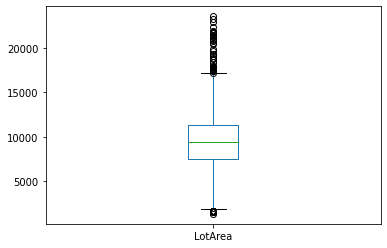

In [ ]:
data_new['LotArea'].plot(kind='box')

## Censoring or Capping.

**Censoring**, or **capping**, means capping the maximum and /or minimum of a distribution at an arbitrary value. 

In [ ]:
data["LotArea"].describe()

count      1460.000000
mean      10516.828082
std        9981.264932
min        1300.000000
25%        7553.500000
50%        9478.500000
75%       11601.500000
max      215245.000000
Name: LotArea, dtype: float64

In [ ]:
IQR= data["LotArea"].quantile(0.75)-data["LotArea"].quantile(0.25)

In [ ]:
upper_bound = data["LotArea"].quantile(0.75) + 3* IQR #robust
under_bound = data["LotArea"].quantile(0.25) - 3* IQR #robust

In [ ]:
data['LotArea_capping']= np.where(data["LotArea"]>upper_bound,upper_bound,
                                  np.where(data["LotArea"]<under_bound,under_bound,data["LotArea"]))

In [ ]:
data['LotArea_capping'].describe()

count     1460.000000
mean      9850.709589
std       4152.362580
min       1300.000000
25%       7553.500000
50%       9478.500000
75%      11601.500000
max      23745.500000
Name: LotArea_capping, dtype: float64

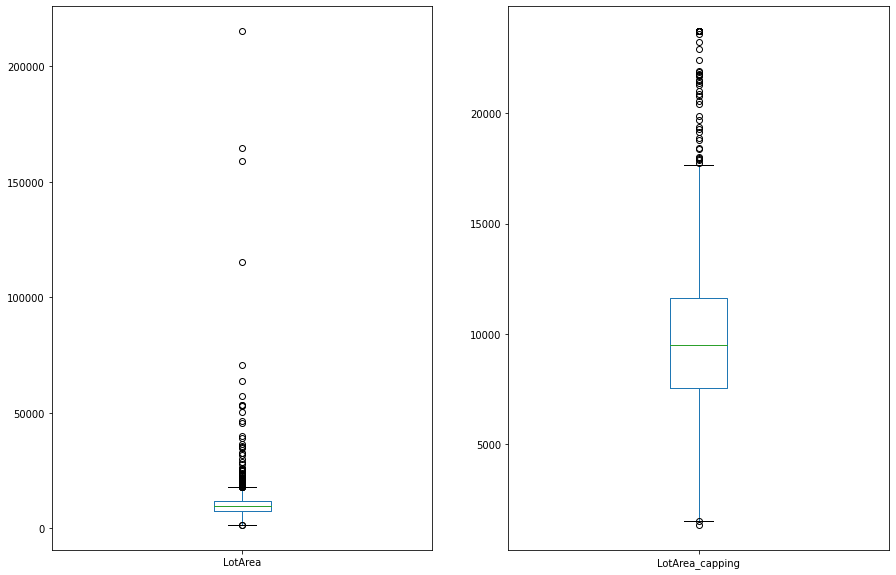

In [ ]:
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(121)
data['LotArea'].plot(kind='box')
ax = fig.add_subplot(122)
data['LotArea_capping'].plot(kind='box')